# Hyperparameter Grid Search

This notebook contains code to perform grid searches over hyperparameter combinations for the various training algorithms tested for this project

For each algorithm tested the hyperparameters explored are the following


##### PC
| Parameter | Role |
|-----------|------|
| `ci_test` | Conditional independence test (e.g. `"pearsonr"` for continuous Gaussian data, `"chi_square"` / `"g_sq"` for discrete) |
| `significance_level` | Alpha threshold, lower values yield sparser graphs (fewer edges kept after CI tests) |
| `max_cond_vars` | Maximum conditioning-set size, limits the depth of the skeleton-finding phase; `None` = no limit |

##### FGES
| Parameter | Role | Values |
|-----------|------|--------|
| `method` | BIC scoring variant | `scatter` (covariance-based), `r2` (adjusted R²) |

##### NOTEARS
| Parameter | Role |
|-----------|------|
| `lambda1` | L1 penalty, higher values push edge weights toward zero (sparser graphs) |
| `w_threshold` | Post-optimisation cutoff, edges with `\|weight\| < w_threshold` are pruned |

##### DAG-GNN
| Parameter | Role |
|-----------|------|
| `graph_threshold` | Post-training cutoff — edges with weight below this value are pruned (controls output sparsity) |
| `encoder_hidden` | Hidden-layer width of the VAE encoder — larger values increase model capacity |
| `epochs` | Number of training epochs — more epochs allow better convergence but increase runtime |

In [2]:
%load_ext autoreload
%autoreload 2

import warnings
import logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from data import *
from reporting import plot_hyperparam_sensitivity, print_summary, METRIC_COLUMNS
from training import grid_search

logging.getLogger('castle').setLevel(logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def _marginal(results_df, param_grid, row_param, col_param):
    """Average metrics over all parameters except the given pair."""
    other = [p for p in param_grid if p not in (row_param, col_param)]
    return (
        results_df.groupby([row_param, col_param])[METRIC_COLUMNS].mean().reset_index()
        if other else results_df
    )


def plot_scatter(results_df, param_grid):
    """Precision–Recall scatter for all combinations.
    First two params drive color/marker; any extras are averaged out.
    Bubble size is proportional to SHD (smaller = better)."""
    param_names = list(param_grid.keys())
    p0, p1 = param_names[0], param_names[1]
    df     = _marginal(results_df, param_grid, p0, p1)
    p0_vals = sorted(df[p0].unique())
    p1_vals = sorted(df[p1].unique())
    colors  = plt.cm.tab10(np.linspace(0, 1, len(p0_vals)))
    markers = ["o", "s", "^", "D", "v", "P"]
    fig, ax = plt.subplots(figsize=(8, 6))
    for p0_idx, p0_val in enumerate(p0_vals):
        for _, row in df[df[p0] == p0_val].iterrows():
            p1_idx = p1_vals.index(row[p1])
            ax.scatter(row["precision"], row["recall"],
                       s=row["shd"] * 6 + 20,
                       color=colors[p0_idx],
                       marker=markers[p1_idx % len(markers)],
                       alpha=0.8, edgecolors="white", linewidths=0.5)
            ax.annotate(f"({p0_val},{row[p1]})",
                        (row["precision"], row["recall"]),
                        textcoords="offset points", xytext=(5, 3), fontsize=7, alpha=0.7)
    other = [p for p in param_names if p not in (p0, p1)]
    extra = f"  (avg over: {', '.join(other)})" if other else ""
    ax.set_title(f"Precision–Recall: {p0} × {p1}{extra}\n(bubble ∝ SHD)", fontsize=12)
    ax.set_xlabel("Precision"); ax.set_ylabel("Recall")
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color="grey", lw=0.5, ls="--")
    ax.axvline(0.5, color="grey", lw=0.5, ls="--")
    ax.grid(alpha=0.3)
    handles = [mpatches.Patch(color=colors[i], label=f"{p0}={v}") for i, v in enumerate(p0_vals)]
    ax.legend(handles=handles, title=p0, fontsize=8, loc="lower right")
    fig.tight_layout()
    plt.show()


def search_and_report(df, gt_dag, param_grid, algorithm: str):
    best_result, results_df = grid_search(df, algorithm, param_grid, gt_dag)
    best_params = results_df.loc[results_df["shd"].idxmin(), list(param_grid.keys())].to_dict()
    print(f"Best SHD: {results_df['shd'].min():.0f}  params: {best_params}")
    print(results_df)

    plot_hyperparam_sensitivity(results_df)
    # plot_scatter(results_df, param_grid)
    print_summary(results_df)


## Sachs et al.

This section of the notebook contains hyper-parameter search for the Sachs et al. protein dataset (11 variables)

In [4]:
sachs_df, sachs_dag  = load_sachs()
print(f"Sachs: {sachs_df.shape[0]} samples, {sachs_df.shape[1]} nodes, {len(sachs_dag.edges())} true edges")


Sachs: 11672 samples, 11 nodes, 20 true edges


### NOTEARS

In [5]:
SACHS_PARAM_GRID = {
    "lambda1":     [0.01, 0.05, 0.1, 0.2, 0.5],
    "w_threshold": [0.3, 0.5, 0.6],
}

best_result_sachs, results_df_sachs = grid_search(sachs_df, "notears", SACHS_PARAM_GRID, sachs_dag)
best_params_sachs = results_df_sachs.loc[results_df_sachs["shd"].idxmin(), list(SACHS_PARAM_GRID.keys())].to_dict()
print(f"Best SHD: {results_df_sachs['shd'].min():.0f}  params: {best_params_sachs}")
results_df_sachs

2026-07-04 23:47:14,446 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=11672, d=11, iter_=100, h_=1e-08, rho_=10000000000000000


Grid: 5 × 3 = 15 combinations



2026-07-04 23:47:16,169 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=2.495e+00, loss=543643.397, rho=1.0e+00
2026-07-04 23:47:16,218 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.492e+00, loss=259284.164, rho=1.0e+00
2026-07-04 23:47:16,391 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.464e+00, loss=259312.179, rho=1.0e+01
2026-07-04 23:47:16,778 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.251e+00, loss=259592.326, rho=1.0e+02
2026-07-04 23:47:17,621 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradie

Best SHD: 18  params: {'lambda1': 0.01, 'w_threshold': 0.6}


,lambda1,w_threshold,n_learned,shd,shd_normalized,accuracy,precision,recall,f1,tp,fp,fn,reversed
0,0.01,0.3,18,22,1.1,0.214286,0.333333,0.30,0.315789,6,8,10,4
1,0.01,0.5,13,20,1.0,0.200000,0.384615,0.25,0.303030,5,5,12,3
2,0.01,0.6,10,18,0.9,0.217391,0.500000,0.25,0.333333,5,3,13,2
3,0.05,0.3,18,22,1.1,0.214286,0.333333,0.30,0.315789,6,8,10,4
4,0.05,0.5,12,20,1.0,0.200000,0.416667,0.25,0.312500,5,5,13,2
5,0.05,0.6,10,18,0.9,0.217391,0.500000,0.25,0.333333,5,3,13,2
6,0.10,0.3,18,22,1.1,0.214286,0.333333,0.30,0.315789,6,8,10,4
7,0.10,0.5,13,20,1.0,0.200000,0.384615,0.25,0.303030,5,5,12,3
8,0.10,0.6,10,18,0.9,0.217391,0.500000,0.25,0.333333,5,3,13,2
9,0.20,0.3,18,22,1.1,0.214286,0.333333,0.30,0.315789,6,8,10,4


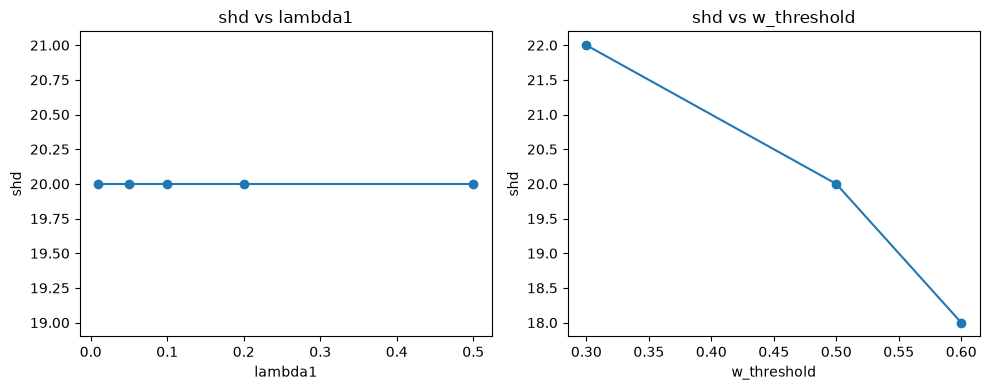

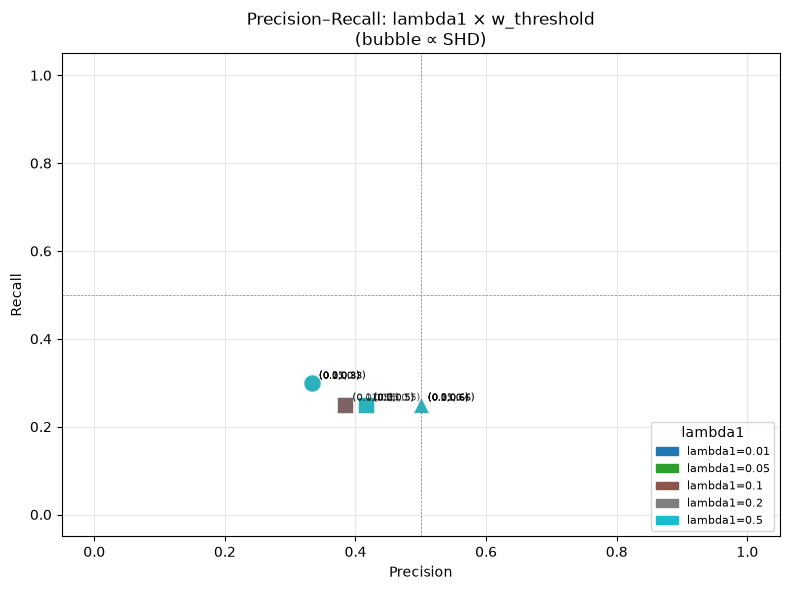

Top 5 combinations by shd
 lambda1  w_threshold    f1  precision  recall  shd  n_learned
    0.01          0.6 0.333        0.5    0.25   18         10
    0.05          0.6 0.333        0.5    0.25   18         10
    0.20          0.6 0.333        0.5    0.25   18         10
    0.10          0.6 0.333        0.5    0.25   18         10
    0.50          0.6 0.333        0.5    0.25   18         10

Recommended: lambda1=0.01, w_threshold=0.6
  F1=0.333  Precision=0.500  Recall=0.250  SHD=18


In [6]:
plot_hyperparam_sensitivity(results_df_sachs)
plot_scatter(results_df_sachs, SACHS_PARAM_GRID)
print_summary(results_df_sachs)


### PC

Grid: 1 × 6 × 4 = 24 combinations



2026-07-05 00:21:15,644 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 00:21:19,247 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 00:21:24,379 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 00:21:30,675 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 00:21:32,714 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discove

Best SHD: 30  params: {'ci_test': 'pearsonr', 'significance_level': 0.001, 'max_cond_vars': nan}
     ci_test  significance_level  max_cond_vars  n_learned  shd  \
0   pearsonr               0.001            2.0         36   35   
1   pearsonr               0.001            3.0         29   31   
2   pearsonr               0.001            4.0         29   31   
3   pearsonr               0.001            NaN         28   30   
4   pearsonr               0.005            2.0         36   35   
5   pearsonr               0.005            3.0         36   35   
6   pearsonr               0.005            4.0         30   33   
7   pearsonr               0.005            NaN         31   33   
8   pearsonr               0.010            2.0         46   42   
9   pearsonr               0.010            3.0         35   35   
10  pearsonr               0.010            4.0         35   35   
11  pearsonr               0.010            NaN         32   32   
12  pearsonr               0.050

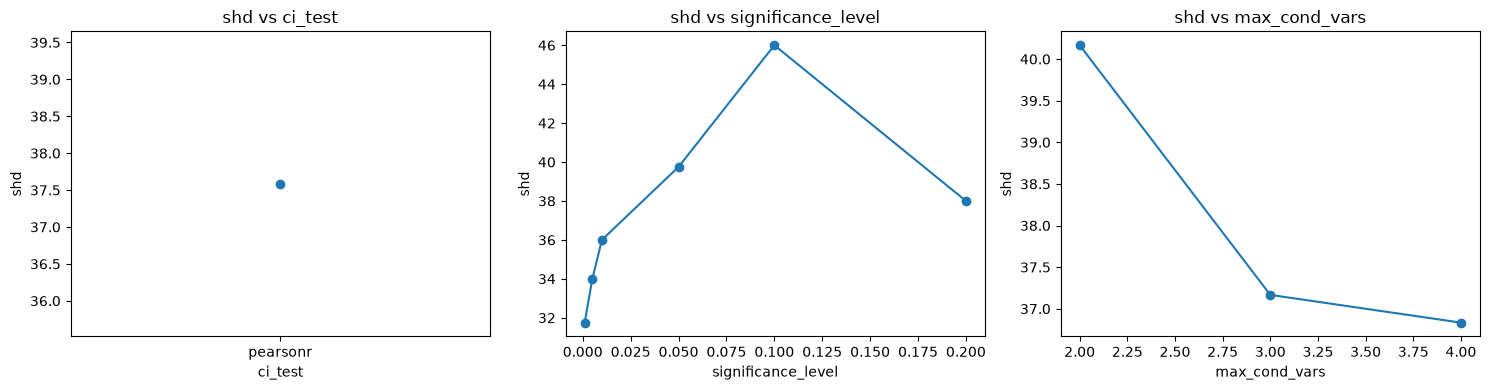

Top 5 combinations by shd
 ci_test  significance_level  max_cond_vars    f1  precision  recall  shd  n_learned
pearsonr               0.001            NaN 0.275      0.250   0.304   30         28
pearsonr               0.001            3.0 0.269      0.241   0.304   31         29
pearsonr               0.001            4.0 0.269      0.241   0.304   31         29
pearsonr               0.010            NaN 0.286      0.250   0.333   32         32
pearsonr               0.005            4.0 0.192      0.167   0.227   33         30

Recommended: ci_test=pearsonr, significance_level=0.001, max_cond_vars=nan
  F1=0.275  Precision=0.250  Recall=0.304  SHD=30


In [7]:
PC_PARAM_GRID = {
    "ci_test":            ["pearsonr"],
    "significance_level": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "max_cond_vars":      [2, 3, 4, None],
}
search_and_report(sachs_df, sachs_dag, PC_PARAM_GRID, "pc")

### FGES

In [8]:
FGES_SACHS_PARAM_GRID = {
    "method": ["scatter", "r2"],
}

best_result_fges_sachs, results_df_fges_sachs = grid_search(sachs_df, "fges", FGES_SACHS_PARAM_GRID, sachs_dag)
best_params_fges_sachs = results_df_fges_sachs.loc[
    results_df_fges_sachs["shd"].idxmin(), list(FGES_SACHS_PARAM_GRID.keys())
].to_dict()
print(f"Best SHD: {results_df_fges_sachs['shd'].min():.0f}  params: {best_params_fges_sachs}")
results_df_fges_sachs

Grid: 2 = 2 combinations

Best SHD: 26  params: {'method': 'r2'}


,method,n_learned,shd,shd_normalized,accuracy,precision,recall,f1,tp,fp,fn,reversed
0,scatter,35,33,1.65,0.195122,0.228571,0.363636,0.280702,8,19,6,8
1,r2,20,26,1.30,0.235294,0.363636,0.285714,0.320000,8,6,12,8


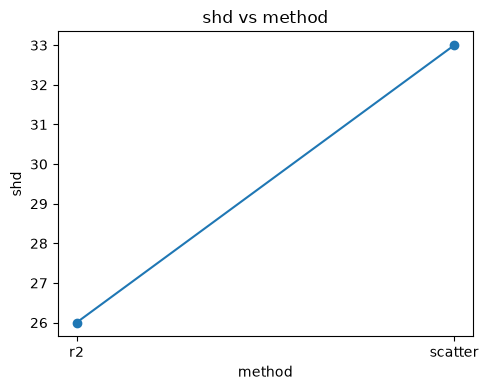

Top 5 combinations by shd
 method    f1  precision  recall  shd  n_learned
     r2 0.320      0.364   0.286   26         20
scatter 0.281      0.229   0.364   33         35

Recommended: method=r2
  F1=0.320  Precision=0.364  Recall=0.286  SHD=26


In [9]:
plot_hyperparam_sensitivity(results_df_fges_sachs)
print_summary(results_df_fges_sachs)


### DAG-GNN

Grid: 2 × 2 × 2 × 3 = 24 combinations



2026-07-05 00:23:19,418 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:165] - INFO: GPU is available.
2026-07-05 00:24:12,458 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 0, epoch: 99, h_new: 2.0854441677082782
2026-07-05 00:25:56,529 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 1, epoch: 99, h_new: 0.5146999555842822
2026-07-05 00:27:44,840 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 2, epoch: 99, h_new: 0.11419735780291873
2026-07-05 00:30:19,698 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/da

Best SHD: 20  params: {'mlp_dimension': 32.0, 'epochs': 100.0, 'lr': 0.03, 'graph_threshold': 0.3}
    mlp_dimension  epochs     lr  graph_threshold  n_learned  shd  \
0              32     100  0.003              0.0        121  103   
1              32     100  0.003              0.1         41   35   
2              32     100  0.003              0.3         27   27   
3              32     100  0.030              0.0        121  103   
4              32     100  0.030              0.1          2   22   
5              32     100  0.030              0.3          0   20   
6              32     300  0.003              0.0        121  103   
7              32     300  0.003              0.1         42   38   
8              32     300  0.003              0.3         24   29   
9              32     300  0.030              0.0        121  103   
10             32     300  0.030              0.1          1   21   
11             32     300  0.030              0.3          0   20   
12  

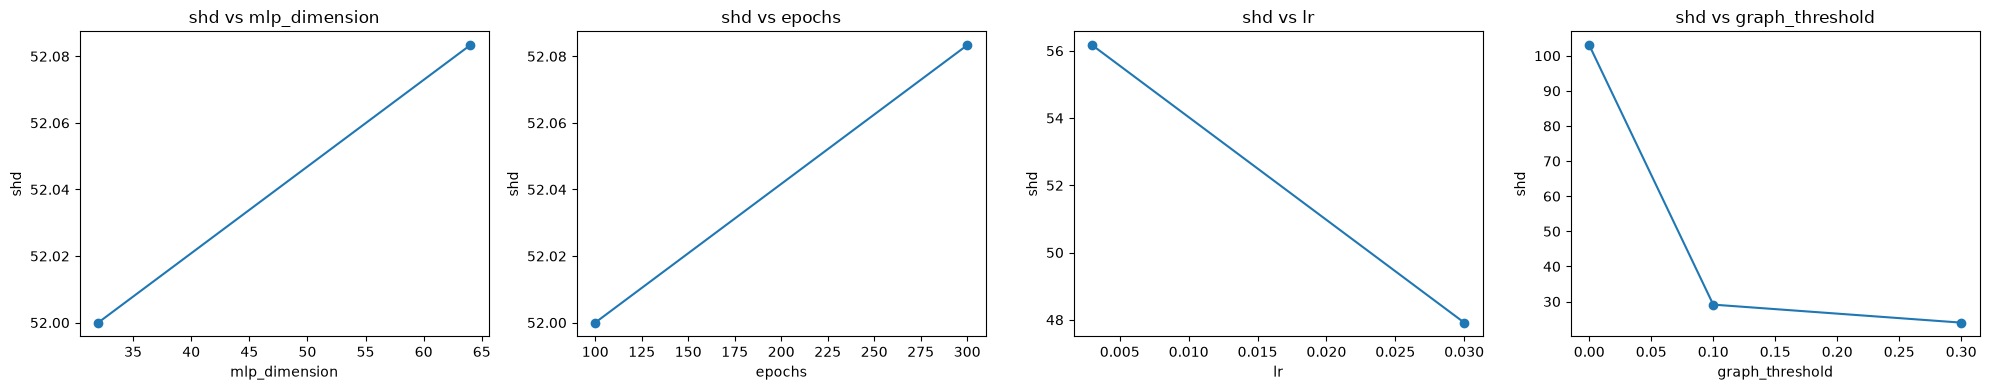

Top 5 combinations by shd
 mlp_dimension  epochs   lr  graph_threshold  f1  precision  recall  shd  n_learned
            32     100 0.03              0.3 0.0        0.0     0.0   20          0
            32     300 0.03              0.3 0.0        0.0     0.0   20          0
            64     100 0.03              0.3 0.0        0.0     0.0   20          0
            64     100 0.03              0.1 0.0        0.0     0.0   20          4
            64     300 0.03              0.3 0.0        0.0     0.0   20          0

Recommended: mlp_dimension=32.0, epochs=100.0, lr=0.03, graph_threshold=0.3
  F1=0.000  Precision=0.000  Recall=0.000  SHD=20


In [10]:
DAGGNN_SACHS_PARAM_GRID = {
    "mlp_dimension":  [32, 64],
    "epochs":          [100, 300],
    "lr":        [0.003, 0.03],
    "graph_threshold": [0.0, 0.1, 0.3]
}
search_and_report(sachs_df, sachs_dag, DAGGNN_SACHS_PARAM_GRID, "daggnn")

## Cancer

This section of the notebook contains hyper-parameter search for the cancer dataset (5 variables)


In [11]:
cancer_df, cancer_dag = load_cancer(1000, SEED)
print(f"Cancer: {cancer_df.shape[0]} samples, {cancer_df.shape[1]} nodes, {len(cancer_dag.edges())} true edges")

Generating for node: Dyspnoea: 100%|██████████| 5/5 [00:00<00:00, 23.27it/s] 

Cancer: 1000 samples, 5 nodes, 4 true edges


### NOTEARS

2026-07-05 18:26:54,237 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=5, iter_=100, h_=1e-08, rho_=10000000000000000
2026-07-05 18:26:54,244 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=8.105e-07, loss=0.347, rho=1.0e+00
2026-07-05 18:26:54,246 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+00
2026-07-05 18:26:54,248 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+01
2026-07-05 18:26:54,250 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradie

Grid: 4 × 3 = 12 combinations



2026-07-05 18:26:54,410 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 3] h=6.128e-09, loss=0.347, rho=1.0e+10
2026-07-05 18:26:54,410 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:222] - INFO: FINISHED
2026-07-05 18:26:54,411 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=5, iter_=100, h_=1e-08, rho_=10000000000000000
2026-07-05 18:26:54,413 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=0.000e+00, loss=0.347, rho=1.0e+00
2026-07-05 18:26:54,414 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:222] - INFO

Best SHD: 3  params: {'lambda1': 0.01, 'w_threshold': 0.05}
    lambda1  w_threshold  n_learned  shd  shd_normalized  accuracy  precision  \
0      0.01         0.05          1    3            0.75      0.25        1.0   
1      0.01         0.10          1    3            0.75      0.25        1.0   
2      0.01         0.20          0    4            1.00      0.00        0.0   
3      0.05         0.05          0    4            1.00      0.00        0.0   
4      0.05         0.10          0    4            1.00      0.00        0.0   
5      0.05         0.20          0    4            1.00      0.00        0.0   
6      0.10         0.05          0    4            1.00      0.00        0.0   
7      0.10         0.10          0    4            1.00      0.00        0.0   
8      0.10         0.20          0    4            1.00      0.00        0.0   
9      0.20         0.05          0    4            1.00      0.00        0.0   
10     0.20         0.10          0    4         

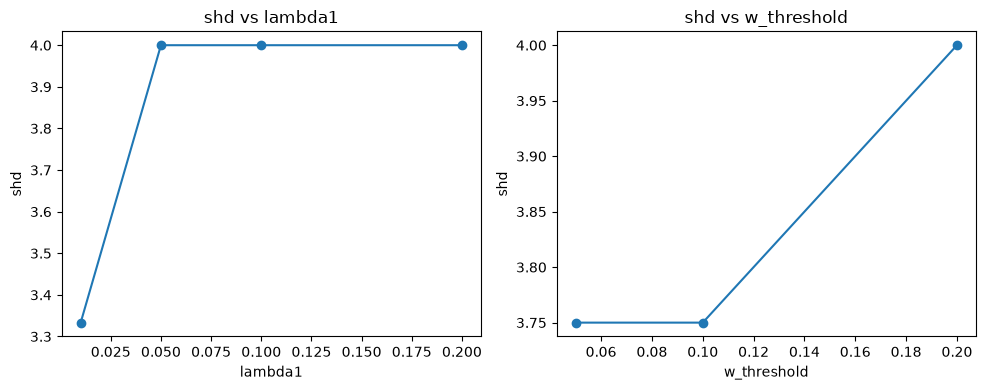

Top 5 combinations by shd
 lambda1  w_threshold  f1  precision  recall  shd  n_learned
    0.01         0.05 0.4        1.0    0.25    3          1
    0.01         0.10 0.4        1.0    0.25    3          1
    0.01         0.20 0.0        0.0    0.00    4          0
    0.05         0.05 0.0        0.0    0.00    4          0
    0.05         0.10 0.0        0.0    0.00    4          0

Recommended: lambda1=0.01, w_threshold=0.05
  F1=0.400  Precision=1.000  Recall=0.250  SHD=3


In [ ]:
NOTEARS_CANCER_PARAM_GRID = {
    "lambda1":     [0.01, 0.05, 0.1, 0.2],
    "w_threshold": [0.0, 0.05, 0.1, 0.2],
}
search_and_report(cancer_df, cancer_dag, NOTEARS_CANCER_PARAM_GRID, "notears")

### PC

2026-07-05 18:26:54,714 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting


Grid: 1 × 6 × 4 = 24 combinations



2026-07-05 18:26:54,868 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 18:26:54,919 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 18:26:55,072 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 18:26:55,148 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 18:26:55,235 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discove

Best SHD: 2  params: {'ci_test': 'pearsonr', 'significance_level': 0.005, 'max_cond_vars': 2.0}
     ci_test  significance_level  max_cond_vars  n_learned  shd  \
0   pearsonr               0.001            2.0          2    3   
1   pearsonr               0.001            3.0          2    3   
2   pearsonr               0.001            4.0          2    3   
3   pearsonr               0.001            NaN          2    3   
4   pearsonr               0.005            2.0          3    2   
5   pearsonr               0.005            3.0          3    2   
6   pearsonr               0.005            4.0          3    2   
7   pearsonr               0.005            NaN          3    2   
8   pearsonr               0.010            2.0          4    2   
9   pearsonr               0.010            3.0          4    2   
10  pearsonr               0.010            4.0          4    2   
11  pearsonr               0.010            NaN          4    2   
12  pearsonr               0.050 

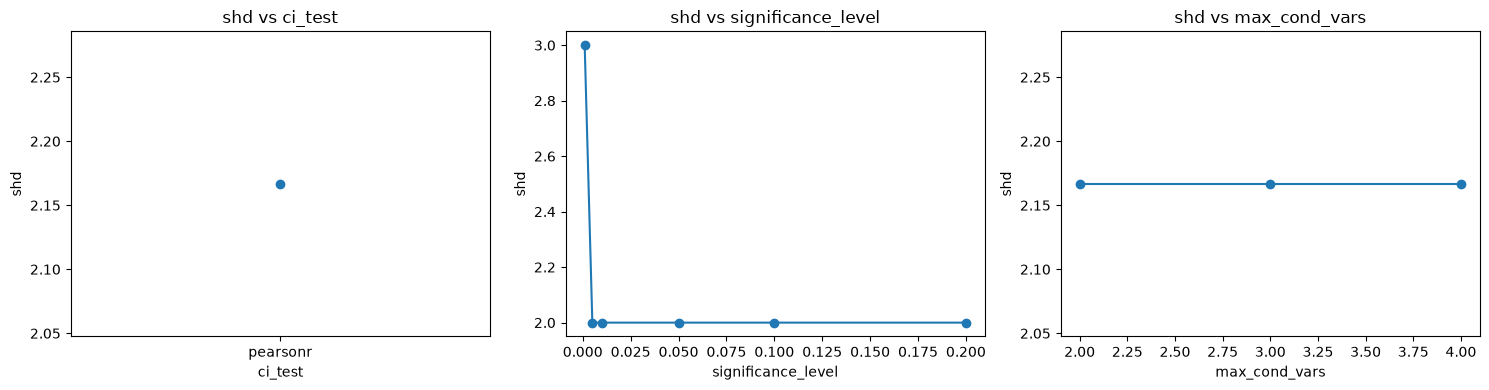

Top 5 combinations by shd
 ci_test  significance_level  max_cond_vars    f1  precision  recall  shd  n_learned
pearsonr               0.005            NaN 0.571      0.667     0.5    2          3
pearsonr               0.005            4.0 0.571      0.667     0.5    2          3
pearsonr               0.005            3.0 0.571      0.667     0.5    2          3
pearsonr               0.005            2.0 0.571      0.667     0.5    2          3
pearsonr               0.010            NaN 0.500      0.500     0.5    2          4

Recommended: ci_test=pearsonr, significance_level=0.005, max_cond_vars=nan
  F1=0.571  Precision=0.667  Recall=0.500  SHD=2


In [13]:
PC_CANCER_PARAM_GRID = {
    "ci_test":            ["pearsonr"],
    "significance_level": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "max_cond_vars":      [2, 3, 4, None],
}
search_and_report(cancer_df, cancer_dag, PC_CANCER_PARAM_GRID, "pc")

### FGES

Grid: 2 = 2 combinations

Best SHD: 1  params: {'method': 'scatter'}
    method  n_learned  shd  shd_normalized  accuracy  precision  recall  \
0  scatter          4    1            0.25  0.750000   0.750000    0.75   
1       r2         11   13            3.25  0.071429   0.090909    0.25   

         f1  tp  fp  fn  reversed  
0  0.750000   3   0   0         1  
1  0.133333   1  10   3         0  


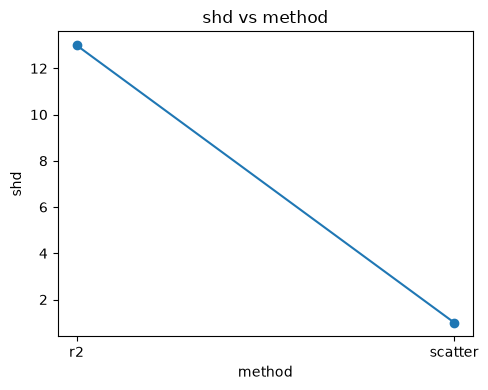

Top 5 combinations by shd
 method    f1  precision  recall  shd  n_learned
scatter 0.750      0.750    0.75    1          4
     r2 0.133      0.091    0.25   13         11

Recommended: method=scatter
  F1=0.750  Precision=0.750  Recall=0.750  SHD=1


In [14]:
FGES_CANCER_PARAM_GRID = {
    "method": ["scatter", "r2"],
}
search_and_report(cancer_df, cancer_dag, FGES_CANCER_PARAM_GRID, "fges")

### DAG-GNN

2026-07-05 18:26:56,856 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:165] - INFO: GPU is available.


Grid: 2 × 2 × 2 × 3 = 24 combinations



2026-07-05 18:27:00,855 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 0, epoch: 99, h_new: 0.0011701504513990102
2026-07-05 18:27:04,926 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 1, epoch: 99, h_new: 0.0011701504513990102
2026-07-05 18:27:17,184 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 2, epoch: 99, h_new: 0.00014469971200536946
2026-07-05 18:27:25,231 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 3, epoch: 99, h_new: 2.9209005552033318e-05
2026-07-05 18:27:33,257 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/ca

Best SHD: 3  params: {'mlp_dimension': 64.0, 'epochs': 100.0, 'lr': 0.003, 'graph_threshold': 0.1}
    mlp_dimension  epochs     lr  graph_threshold  n_learned  shd  \
0              32     100  0.003              0.0         25   21   
1              32     100  0.003              0.1          0    4   
2              32     100  0.003              0.3          0    4   
3              32     100  0.030              0.0         25   21   
4              32     100  0.030              0.1          1    5   
5              32     100  0.030              0.3          0    4   
6              32     300  0.003              0.0         25   21   
7              32     300  0.003              0.1          1    4   
8              32     300  0.003              0.3          0    4   
9              32     300  0.030              0.0         25   21   
10             32     300  0.030              0.1          0    4   
11             32     300  0.030              0.3          0    4   
12  

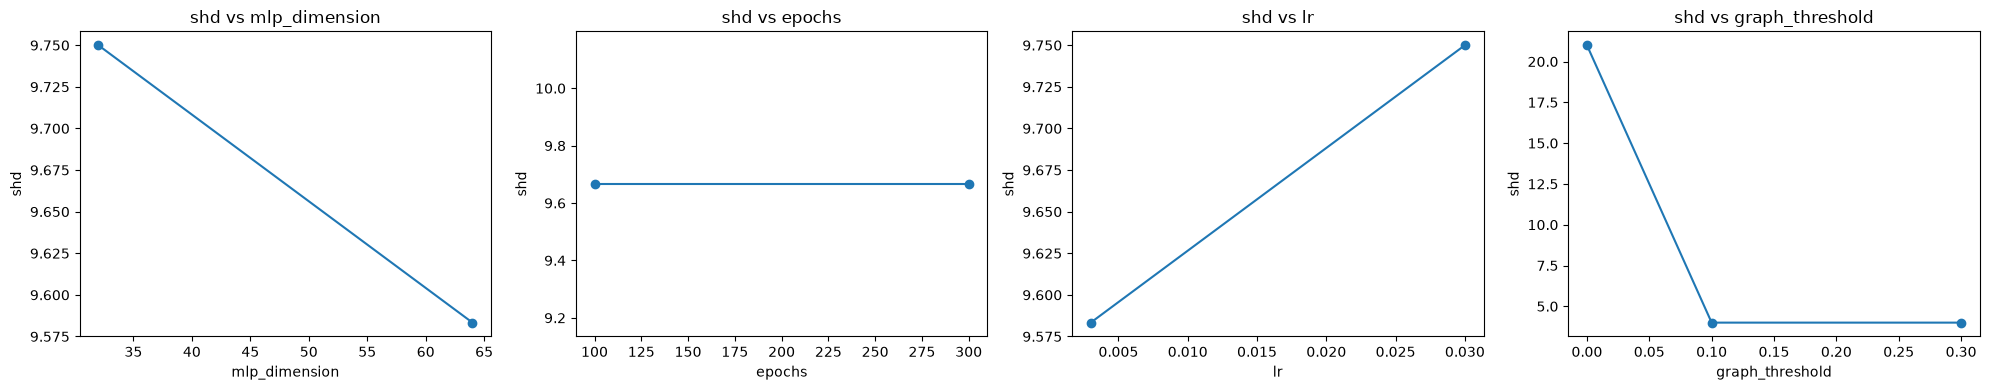

Top 5 combinations by shd
 mlp_dimension  epochs    lr  graph_threshold  f1  precision  recall  shd  n_learned
            64     100 0.003              0.1 0.4        1.0    0.25    3          1
            32     100 0.003              0.1 0.0        0.0    0.00    4          0
            32     300 0.003              0.1 0.0        0.0    0.00    4          1
            32     100 0.003              0.3 0.0        0.0    0.00    4          0
            32     300 0.030              0.1 0.0        0.0    0.00    4          0

Recommended: mlp_dimension=64.0, epochs=100.0, lr=0.003, graph_threshold=0.1
  F1=0.400  Precision=1.000  Recall=0.250  SHD=3


In [15]:
DAGGNN_CANCER_PARAM_GRID = {
    "mlp_dimension":  [32, 64],
    "epochs":          [100, 300],
    "lr":        [0.003, 0.03],
    "graph_threshold": [0.0, 0.1, 0.3]
}
search_and_report(cancer_df, cancer_dag, DAGGNN_CANCER_PARAM_GRID, "daggnn")

## Child

This section of the notebook contains hyper-parameter search for the Child dataset (20 variables)

In [16]:
child_df, child_dag = load_child(1000, SEED)
print(f"Child: {child_df.shape[0]} samples, {child_df.shape[1]} nodes, {len(child_dag.edges())} true edges")

Generating for node: ChestXray:   0%|          | 0/20 [00:00<?, ?it/s]  2026-07-05 19:30:07,227 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/utils/mathext.py[line:90] - WARNING: Probability values don't exactly sum to 1. Differ by: -2.220446049250313e-16. Adjusting values.
2026-07-05 19:30:07,227 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/utils/mathext.py[line:90] - WARNING: Probability values don't exactly sum to 1. Differ by: 2.220446049250313e-16. Adjusting values.
Generating for node: GruntingReport: 100%|██████████| 20/20 [00:00<00:00, 523.40it/s]

Child: 1000 samples, 20 nodes, 25 true edges


### NOTEARS

2026-07-05 19:30:07,282 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=20, iter_=100, h_=1e-08, rho_=10000000000000000
2026-07-05 19:30:07,336 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=2.806e-01, loss=7.422, rho=1.0e+00
2026-07-05 19:30:07,374 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.034e-01, loss=4.134, rho=1.0e+00
2026-07-05 19:30:07,431 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=9.718e-02, loss=4.488, rho=1.0e+01


Grid: 4 × 4 = 16 combinations



2026-07-05 19:30:07,508 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=3.397e-02, loss=8.032, rho=1.0e+02
2026-07-05 19:30:07,575 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 2] h=2.007e-02, loss=4.442, rho=1.0e+02
2026-07-05 19:30:07,679 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 2] h=7.631e-03, loss=4.961, rho=1.0e+03
2026-07-05 19:30:07,739 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 3] h=4.572e-03, loss=4.535, rho=1.0e+03
2026-07-05 19:30:07,836 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py

Best SHD: 21  params: {'lambda1': 0.05, 'w_threshold': 0.3}
    lambda1  w_threshold  n_learned  shd  shd_normalized  accuracy  precision  \
0      0.01          0.1         33   28            1.12  0.243243   0.272727   
1      0.01          0.2         24   23            0.92  0.258065   0.333333   
2      0.01          0.3         18   23            0.92  0.206897   0.333333   
3      0.01          0.5         15   22            0.88  0.185185   0.333333   
4      0.05          0.1         22   23            0.92  0.233333   0.318182   
5      0.05          0.2         19   22            0.88  0.214286   0.315789   
6      0.05          0.3         13   21            0.84  0.192308   0.384615   
7      0.05          0.5          9   22            0.88  0.153846   0.444444   
8      0.10          0.1         15   23            0.92  0.148148   0.266667   
9      0.10          0.2         11   22            0.88  0.153846   0.363636   
10     0.10          0.3         11   22         

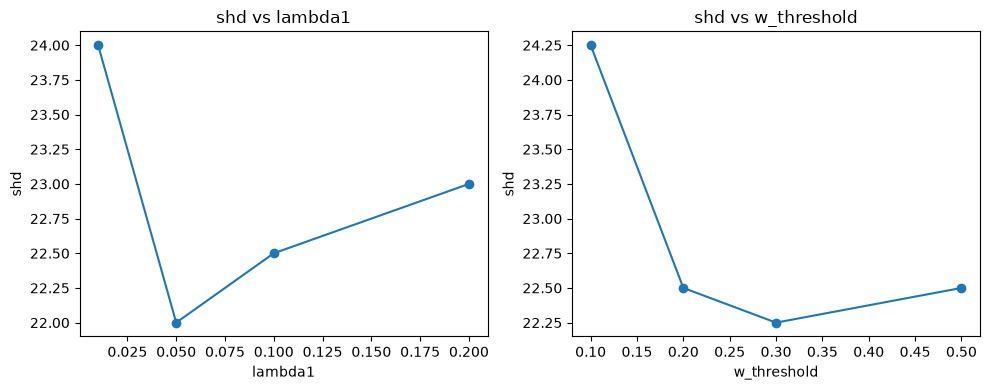

Top 5 combinations by shd
 lambda1  w_threshold    f1  precision  recall  shd  n_learned
    0.05          0.3 0.263      0.385    0.20   21         13
    0.01          0.5 0.250      0.333    0.20   22         15
    0.05          0.2 0.273      0.316    0.24   22         19
    0.05          0.5 0.235      0.444    0.16   22          9
    0.10          0.3 0.222      0.364    0.16   22         11

Recommended: lambda1=0.05, w_threshold=0.3
  F1=0.263  Precision=0.385  Recall=0.200  SHD=21


In [17]:
NOTEARS_CHILD_PARAM_GRID = {
    "lambda1":     [0.01, 0.05, 0.1, 0.2],
    "w_threshold": [0.1, 0.2, 0.3, 0.5],
}
search_and_report(child_df, child_dag, NOTEARS_CHILD_PARAM_GRID, "notears")

### PC

Grid: 1 × 6 × 4 = 24 combinations



2026-07-05 19:31:16,635 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 19:31:17,594 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 19:31:18,564 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 19:31:19,534 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 19:31:20,539 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discove

Best SHD: 26  params: {'ci_test': 'pearsonr', 'significance_level': 0.001, 'max_cond_vars': 3.0}
     ci_test  significance_level  max_cond_vars  n_learned  shd  \
0   pearsonr               0.001            2.0         28   27   
1   pearsonr               0.001            3.0         27   26   
2   pearsonr               0.001            4.0         27   26   
3   pearsonr               0.001            NaN         27   26   
4   pearsonr               0.005            2.0         30   29   
5   pearsonr               0.005            3.0         29   27   
6   pearsonr               0.005            4.0         29   27   
7   pearsonr               0.005            NaN         29   27   
8   pearsonr               0.010            2.0         32   29   
9   pearsonr               0.010            3.0         29   27   
10  pearsonr               0.010            4.0         29   27   
11  pearsonr               0.010            NaN         29   27   
12  pearsonr               0.050

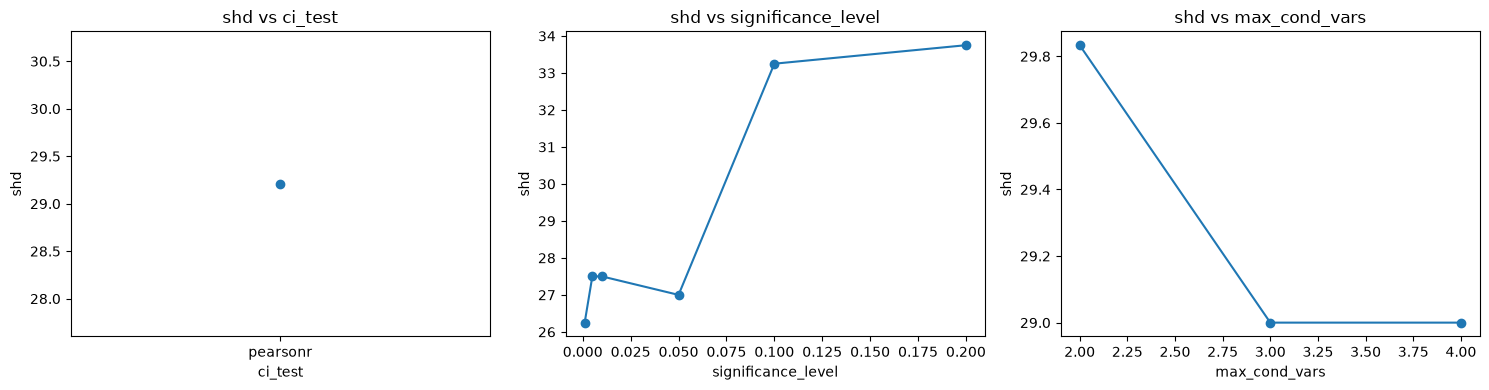

Top 5 combinations by shd
 ci_test  significance_level  max_cond_vars    f1  precision  recall  shd  n_learned
pearsonr               0.001            3.0 0.286      0.296   0.276   26         27
pearsonr               0.001            4.0 0.286      0.296   0.276   26         27
pearsonr               0.001            NaN 0.286      0.296   0.276   26         27
pearsonr               0.001            2.0 0.281      0.286   0.276   27         28
pearsonr               0.005            3.0 0.305      0.310   0.300   27         29

Recommended: ci_test=pearsonr, significance_level=0.001, max_cond_vars=3.0
  F1=0.286  Precision=0.296  Recall=0.276  SHD=26


In [18]:
PC_CHILD_PARAM_GRID = {
    "ci_test":            ["pearsonr"],
    "significance_level": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "max_cond_vars":      [2, 3, 4, None],
}
search_and_report(child_df, child_dag, PC_CHILD_PARAM_GRID, "pc")

### FGES

Grid: 2 = 2 combinations

Best SHD: 27  params: {'method': 'scatter'}
    method  n_learned  shd  shd_normalized  accuracy  precision    recall  \
0  scatter         38   27            1.08  0.372093   0.421053  0.533333   
1       r2         63   75            3.00  0.050633   0.063492  0.142857   

         f1  tp  fp  fn  reversed  
0  0.470588  16  13   5         9  
1  0.087912   4  51  16         8  


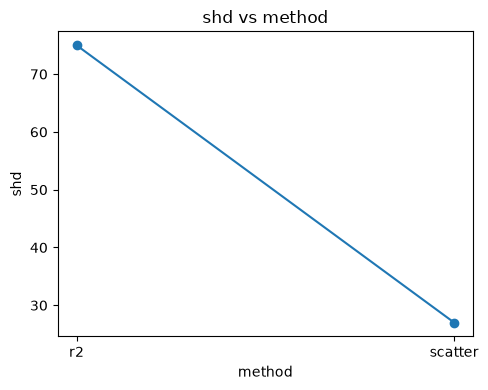

Top 5 combinations by shd
 method    f1  precision  recall  shd  n_learned
scatter 0.471      0.421   0.533   27         38
     r2 0.088      0.063   0.143   75         63

Recommended: method=scatter
  F1=0.471  Precision=0.421  Recall=0.533  SHD=27


In [19]:
FGES_CHILD_PARAM_GRID = {
    "method": ["scatter", "r2"],
}
search_and_report(child_df, child_dag, FGES_CHILD_PARAM_GRID, "fges")

### DAG-GNN

2026-07-05 19:32:31,773 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:165] - INFO: GPU is available.


Grid: 3 × 2 × 3 × 3 = 54 combinations



2026-07-05 19:32:36,408 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 0, epoch: 99, h_new: 0.044952160079553494
2026-07-05 19:32:45,409 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 1, epoch: 99, h_new: 0.007597901580513877
2026-07-05 19:32:54,496 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 2, epoch: 99, h_new: 0.0016712690645732664
2026-07-05 19:33:03,662 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 3, epoch: 99, h_new: 0.00035128634969439076
2026-07-05 19:33:12,915 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castl

Best SHD: 24  params: {'mlp_dimension': 32.0, 'epochs': 100.0, 'lr': 0.003, 'graph_threshold': 0.3}
    mlp_dimension  epochs      lr  graph_threshold  n_learned  shd  \
0              32     100  0.0003              0.0        400  375   
1              32     100  0.0003              0.1         52   45   
2              32     100  0.0003              0.3         22   27   
3              32     100  0.0030              0.0        400  375   
4              32     100  0.0030              0.1         41   41   
5              32     100  0.0030              0.3         17   24   
6              32     100  0.0300              0.0        400  375   
7              32     100  0.0300              0.1         21   46   
8              32     100  0.0300              0.3          0   25   
9              32     300  0.0003              0.0        400  375   
10             32     300  0.0003              0.1         46   42   
11             32     300  0.0003              0.3         1

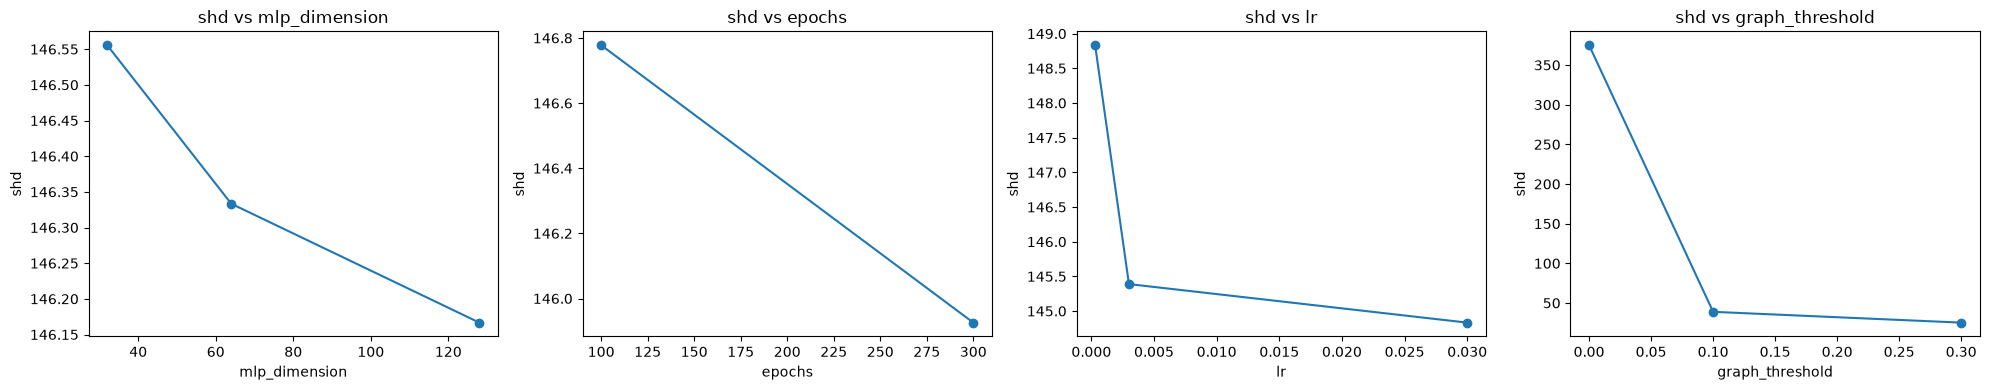

Top 5 combinations by shd
 mlp_dimension  epochs    lr  graph_threshold    f1  precision  recall  shd  n_learned
            32     100 0.003              0.3 0.238      0.294     0.2   24         17
           128     300 0.003              0.3 0.238      0.294     0.2   24         17
           128     100 0.003              0.3 0.238      0.294     0.2   24         17
            64     300 0.003              0.3 0.238      0.294     0.2   24         17
            32     300 0.030              0.3 0.000      0.000     0.0   25          0

Recommended: mlp_dimension=32.0, epochs=100.0, lr=0.003, graph_threshold=0.3
  F1=0.238  Precision=0.294  Recall=0.200  SHD=24


In [20]:
DAGGNN_CHILD_PARAM_GRID = {
    "mlp_dimension":  [32, 64, 128],
    "epochs":          [100, 300],
    "lr": [0.0003, 0.003, 0.03],
    "graph_threshold": [0.0, 0.1, 0.3]
}
search_and_report(child_df, child_dag, DAGGNN_CHILD_PARAM_GRID, "daggnn")

## Alarm

This section of the notebook contains hyper-parameter search for the Alarm dataset (37 variables)

In [21]:
alarm_df, alarm_dag = load_alarm(1000, SEED)
print(f"Alarm: {alarm_df.shape[0]} samples, {alarm_df.shape[1]} nodes, {len(alarm_dag.edges())} true edges")

Generating for node: BP: 100%|██████████| 37/37 [00:00<00:00, 586.20it/s]

Alarm: 1000 samples, 37 nodes, 46 true edges


### NOTEARS

2026-07-05 22:50:46,376 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=37, iter_=100, h_=1e-08, rho_=10000000000000000


Grid: 4 × 3 = 12 combinations



2026-07-05 22:50:47,112 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=3.143e-01, loss=6.944, rho=1.0e+00
2026-07-05 22:50:47,594 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.102e-01, loss=3.352, rho=1.0e+00
2026-07-05 22:50:48,340 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=9.108e-02, loss=3.797, rho=1.0e+01
2026-07-05 22:50:49,127 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=3.008e-02, loss=8.242, rho=1.0e+02
2026-07-05 22:50:49,836 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py

Best SHD: 34  params: {'lambda1': 0.01, 'w_threshold': 0.2}
    lambda1  w_threshold  n_learned  shd  shd_normalized  accuracy  precision  \
0      0.01          0.1         61   41        0.891304  0.422535   0.491803   
1      0.01          0.2         41   34        0.739130  0.413793   0.585366   
2      0.01          0.3         31   34        0.739130  0.358491   0.612903   
3      0.05          0.1         25   38        0.826087  0.254902   0.520000   
4      0.05          0.2         21   38        0.826087  0.224490   0.523810   
5      0.05          0.3         17   39        0.847826  0.204082   0.588235   
6      0.10          0.1         19   39        0.847826  0.235294   0.631579   
7      0.10          0.2         15   39        0.847826  0.204082   0.666667   
8      0.10          0.3         12   42        0.913043  0.142857   0.583333   
9      0.20          0.1         10   44        0.956522  0.102041   0.500000   
10     0.20          0.2          7   46        1

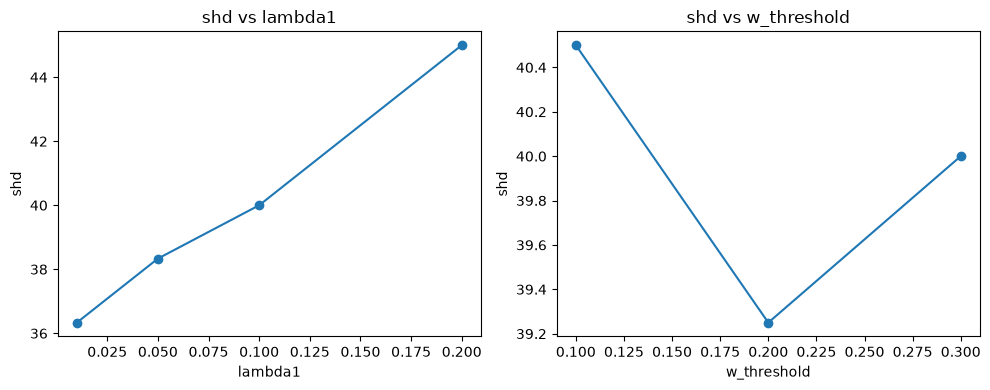

Top 5 combinations by shd
 lambda1  w_threshold    f1  precision  recall  shd  n_learned
    0.01          0.2 0.552      0.585   0.522   34         41
    0.01          0.3 0.494      0.613   0.413   34         31
    0.05          0.1 0.366      0.520   0.283   38         25
    0.05          0.2 0.328      0.524   0.239   38         21
    0.10          0.1 0.369      0.632   0.261   39         19

Recommended: lambda1=0.01, w_threshold=0.2
  F1=0.552  Precision=0.585  Recall=0.522  SHD=34


In [22]:
NOTEARS_BARLEY_PARAM_GRID = {
    "lambda1":     [0.01, 0.05, 0.1, 0.2],
    "w_threshold": [0.1, 0.2, 0.3],
}
search_and_report(alarm_df, alarm_dag, NOTEARS_BARLEY_PARAM_GRID, "notears")

### PC

Grid: 1 × 6 × 4 = 24 combinations



2026-07-05 22:58:58,778 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 22:59:02,108 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 22:59:05,446 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 22:59:13,089 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-05 22:59:17,455 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discove

Best SHD: 29  params: {'ci_test': 'pearsonr', 'significance_level': 0.01, 'max_cond_vars': 2.0}
     ci_test  significance_level  max_cond_vars  n_learned  shd  \
0   pearsonr               0.001            2.0         46   35   
1   pearsonr               0.001            3.0         46   35   
2   pearsonr               0.001            4.0         46   35   
3   pearsonr               0.001            NaN         46   35   
4   pearsonr               0.005            2.0         46   31   
5   pearsonr               0.005            3.0         46   31   
6   pearsonr               0.005            4.0         46   31   
7   pearsonr               0.005            NaN         46   31   
8   pearsonr               0.010            2.0         48   29   
9   pearsonr               0.010            3.0         48   29   
10  pearsonr               0.010            4.0         48   29   
11  pearsonr               0.010            NaN         48   29   
12  pearsonr               0.050 

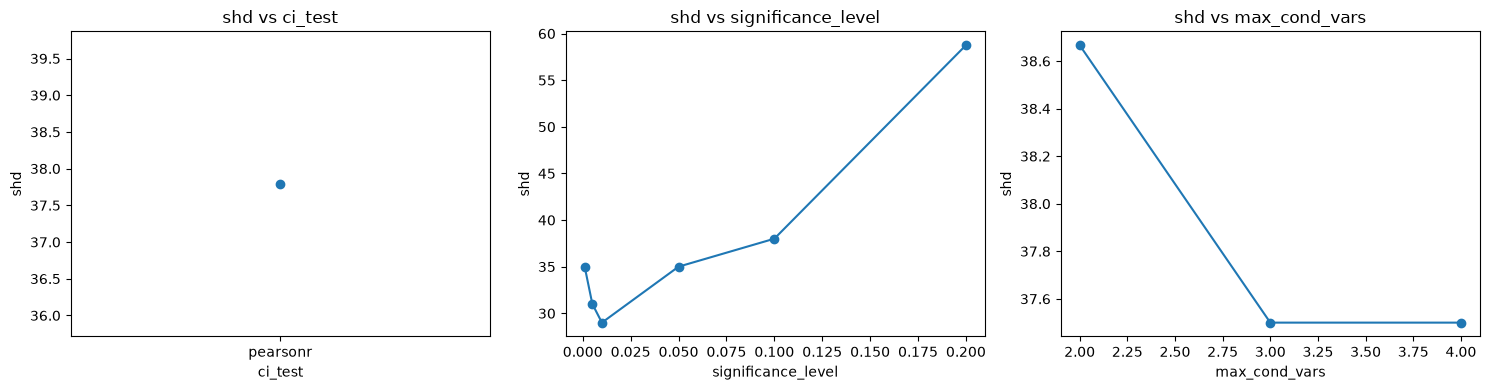

Top 5 combinations by shd
 ci_test  significance_level  max_cond_vars    f1  precision  recall  shd  n_learned
pearsonr               0.010            NaN 0.614      0.646   0.585   29         48
pearsonr               0.010            4.0 0.614      0.646   0.585   29         48
pearsonr               0.010            3.0 0.614      0.646   0.585   29         48
pearsonr               0.010            2.0 0.614      0.646   0.585   29         48
pearsonr               0.005            NaN 0.566      0.609   0.528   31         46

Recommended: ci_test=pearsonr, significance_level=0.01, max_cond_vars=nan
  F1=0.614  Precision=0.646  Recall=0.585  SHD=29


In [23]:
PC_BARLEY_PARAM_GRID = {
    "ci_test":            ["pearsonr"],
    "significance_level": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "max_cond_vars":      [2, 3, 4, None],
}
search_and_report(alarm_df, alarm_dag, PC_BARLEY_PARAM_GRID, "pc")

### FGES

In [24]:
FGES_BARLEY_PARAM_GRID = {
    "method": ["scatter", "r2"],
}
search_and_report(alarm_df, alarm_dag, FGES_BARLEY_PARAM_GRID, "fges")

Grid: 2 = 2 combinations



KeyboardInterrupt: 

### DAG-GNN

2026-07-05 23:13:44,257 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:165] - INFO: GPU is available.


Grid: 3 × 2 × 3 × 3 = 54 combinations



2026-07-05 23:13:49,429 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 0, epoch: 99, h_new: 0.04826470978954944
2026-07-05 23:13:59,557 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 1, epoch: 99, h_new: 0.009264431429969022
2026-07-05 23:14:14,880 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 2, epoch: 99, h_new: 0.0007425114793164767
2026-07-05 23:14:24,996 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 3, epoch: 99, h_new: 0.00011608169192811602
2026-07-05 23:14:34,746 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle

Best SHD: 42  params: {'mlp_dimension': 32.0, 'epochs': 300.0, 'lr': 0.003, 'graph_threshold': 0.3}
    mlp_dimension  epochs      lr  graph_threshold  n_learned   shd  \
0              32     100  0.0003              0.0       1369  1323   
1              32     100  0.0003              0.1        151   126   
2              32     100  0.0003              0.3         42    48   
3              32     100  0.0030              0.0       1369  1323   
4              32     100  0.0030              0.1         65    67   
5              32     100  0.0030              0.3         36    45   
6              32     100  0.0300              0.0       1369  1323   
7              32     100  0.0300              0.1         17    61   
8              32     100  0.0300              0.3          0    46   
9              32     300  0.0003              0.0       1369  1323   
10             32     300  0.0003              0.1        166   140   
11             32     300  0.0003              0

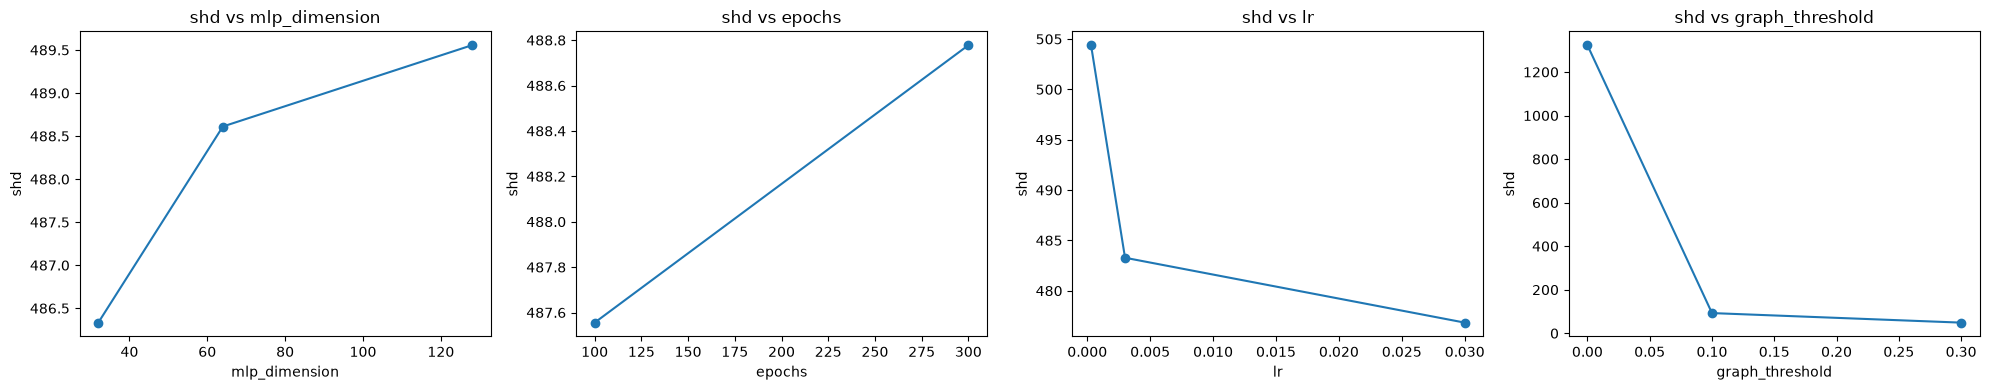

Top 5 combinations by shd
 mlp_dimension  epochs    lr  graph_threshold    f1  precision  recall  shd  n_learned
            32     300 0.003              0.3 0.405      0.485   0.348   42         33
            32     100 0.003              0.3 0.390      0.444   0.348   45         36
           128     300 0.003              0.3 0.390      0.444   0.348   45         36
            32     100 0.030              0.3 0.000      0.000   0.000   46          0
            64     100 0.003              0.3 0.366      0.417   0.326   46         36

Recommended: mlp_dimension=32.0, epochs=300.0, lr=0.003, graph_threshold=0.3
  F1=0.405  Precision=0.485  Recall=0.348  SHD=42


In [25]:
DAGGNN_BARLEY_PARAM_GRID = {
    "mlp_dimension":  [32, 64, 128],
    "epochs":          [100, 300],
    "lr": [0.0003, 0.003, 0.03],
    "graph_threshold": [0.0, 0.1, 0.3]
}
search_and_report(alarm_df, alarm_dag, DAGGNN_BARLEY_PARAM_GRID, "daggnn")